In [1]:
# Import of all libraries
from nasbench import api # Usage of nasbench API
from deap import algorithms, base, creator, tools
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import copy
import random
import math

In [2]:
nasbench = api.NASBench('nasbench_only108.tfrecord')
#nasbench = api.NASBench('nasbench_full.tfrecord')

Loading dataset from file... This may take a few minutes...
Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`
Loaded dataset in 33 seconds


In [3]:
# Definition of the task, inspired by nasbench: https://github.com/google-research/nasbench/blob/master/NASBench.ipynb
# Useful constants
INPUT = 'input'
OUTPUT = 'output'
CONV3X3 = 'conv3x3-bn-relu'
CONV1X1 = 'conv1x1-bn-relu'
MAXPOOL3X3 = 'maxpool3x3'
NUM_VERTICES = 7
MAX_EDGES = 9
EDGE_SPOTS = NUM_VERTICES * (NUM_VERTICES - 1) / 2   # Upper triangular matrix
OP_SPOTS = NUM_VERTICES - 2   # Input/output vertices are fixed
ALLOWED_OPS = [CONV3X3, CONV1X1, MAXPOOL3X3]
ALLOWED_EDGES = [0, 1]   # Binary adjacency matrix

In [4]:
# Definition of the task, inspired by nasbench: https://github.com/google-research/nasbench/blob/master/NASBench.ipynb
# Query an Inception-like cell from the dataset.
cell = api.ModelSpec(
  matrix=[[0, 1, 1, 1, 0, 1, 0],    # input layer
          [0, 0, 0, 0, 0, 0, 1],    # 1x1 conv
          [0, 0, 0, 0, 0, 0, 1],    # 3x3 conv
          [0, 0, 0, 0, 1, 0, 0],    # 5x5 conv (replaced by two 3x3's)
          [0, 0, 0, 0, 0, 0, 1],    # 5x5 conv (replaced by two 3x3's)
          [0, 0, 0, 0, 0, 0, 1],    # 3x3 max-pool
          [0, 0, 0, 0, 0, 0, 0]],   # output layer
  # Operations at the vertices of the module, matches order of matrix.
  ops=[INPUT, CONV1X1, CONV3X3, CONV3X3, CONV3X3, MAXPOOL3X3, OUTPUT])

# Querying multiple times may yield different results. Each cell is evaluated 3
# times at each epoch budget and querying will sample one randomly.
data = nasbench.query(cell)
for k, v in data.items():
  print('%s: %s' % (k, str(v)))

module_adjacency: [[0 1 1 1 1 0 0]
 [0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1]
 [0 0 0 0 0 1 0]
 [0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0]]
module_operations: ['input', 'conv3x3-bn-relu', 'conv1x1-bn-relu', 'maxpool3x3', 'conv3x3-bn-relu', 'conv3x3-bn-relu', 'output']
trainable_parameters: 2694282
training_time: 1154.361083984375
train_accuracy: 1.0
validation_accuracy: 0.9336938858032227
test_accuracy: 0.9286859035491943


In [5]:
# From nasbench: https://github.com/google-research/nasbench/blob/master/NASBench.ipynb
def random_spec():
  """Returns a random valid spec."""
  while True:
    matrix = np.random.choice(ALLOWED_EDGES, size=(NUM_VERTICES, NUM_VERTICES))
    matrix = np.triu(matrix, 1)
    ops = np.random.choice(ALLOWED_OPS, size=(NUM_VERTICES)).tolist()
    ops[0] = INPUT
    ops[-1] = OUTPUT
    spec = api.ModelSpec(matrix=matrix, ops=ops)
    if nasbench.is_valid(spec):
      return spec

def mutate_spec(old_spec, mutation_rate=1.0):
  """Computes a valid mutated spec from the old_spec."""
  while True:
    new_matrix = copy.deepcopy(old_spec.original_matrix)
    new_ops = copy.deepcopy(old_spec.original_ops)
    edge_mutation_prob = mutation_rate / NUM_VERTICES
    for src in range(0, NUM_VERTICES - 1):
      for dst in range(src + 1, NUM_VERTICES):
        if random.random() < edge_mutation_prob:
          new_matrix[src, dst] = 1 - new_matrix[src, dst]
    
    op_mutation_prob = mutation_rate / OP_SPOTS
    for ind in range(1, NUM_VERTICES - 1):
      if random.random() < op_mutation_prob:
        available = [o for o in nasbench.config['available_ops'] if o != new_ops[ind]]
        new_ops[ind] = random.choice(available)
        
    new_spec = api.ModelSpec(new_matrix, new_ops)
    if nasbench.is_valid(new_spec):
      return new_spec

def run_random_search(max_time_budget=10e6):
  """Run a single roll-out of random search to a fixed time budget."""
  nasbench.reset_budget_counters()
  times, best_valids, best_tests = [0.0], [0.0], [0.0]
  while True:
    spec = random_spec()
    data = nasbench.query(spec)

    # It's important to select models only based on validation accuracy, test
    # accuracy is used only for comparing different search trajectories.
    if data['validation_accuracy'] > best_valids[-1]:
      best_valids.append(data['validation_accuracy'])
      best_tests.append(data['test_accuracy'])
    else:
      best_valids.append(best_valids[-1])
      best_tests.append(best_tests[-1])

    time_spent, _ = nasbench.get_budget_counters()
    times.append(time_spent)
    if time_spent > max_time_budget:
      # Break the first time we exceed the budget.
      break

  return times, best_valids, best_tests

In [38]:
# lightweight Pareto tournament.
# Pareto Tournament Selection (simple multi-criteria GA)
# Determines if one individual dominates another when maximizing both metrics
def dominates(ind1, ind2):
    acc1, params1, _ = ind1
    acc2, params2, _ = ind2
    
    # Both metrics should be maximized
    acc_better = acc1 >= acc2
    params_better = params1 >= params2
    
    # Strictly better in at least one
    strictly_better = (acc1 > acc2) or (params1 > params2)
    
    return acc_better and params_better and strictly_better

# Tournament selection preferring architectures with:
# higher accuracy and larger parameter counts
def select_parent(population, tournament_size):
    tournament = random.sample(population, tournament_size)
    
    # Find solutions not dominated by others in tournament
    non_dominated = []
    for ind in tournament:
        is_dominated = False
        for other in tournament:
            if other != ind and dominates(other, ind):
                is_dominated = True
                break
        if not is_dominated:
            non_dominated.append(ind)
    
    # Randomly select from non-dominated, or entire tournament if none
    return random.choice(non_dominated if non_dominated else tournament)[2]

# Crossover function
def crossover(parent1, parent2):
    # Merge adjacency matrices
    matrix_shape = parent1.original_matrix.shape # Dimension of the matrix
    mask = np.random.rand(*matrix_shape) # random matrix of same shape
    
    # Choose parents1 value if random > 0.5, else parents2
    new_matrix = np.where(mask > 0.5, parent1.original_matrix, parent2.original_matrix)
    
    # Merge operations
    new_ops = []
    for p1_op, p2_op in zip(parent1.original_ops, parent2.original_ops):
        if random.random() > 0.5:
            new_ops.append(p1_op)
        else:
            new_ops.append(p2_op)
    
    # Get all metrics from dataset for this new CNN
    new_spec = api.ModelSpec(new_matrix, new_ops)
    
    if nasbench.is_valid(new_spec):
        return new_spec
    else:
        return parent1

# GA algorithm, which combines crossover with mutation
def run_GA_cross(max_time_budget=10e6,
                 population_size=1000,
                 mutation_rate=1.0,
                 tournament_size=20,
                 crossover_rate=0.8,
                 elitism=5
                ):
    nasbench.reset_budget_counters()
    times, best_valids, best_tests = [0.0], [0.0], [0.0]
    population = []  # Stores (validation_accuracy, num_params, spec)

    # Initial population
    for _ in range(population_size):
        spec = random_spec()
        data = nasbench.query(spec)
        val_acc = data['validation_accuracy']
        num_params = data['trainable_parameters']
        time_spent, _ = nasbench.get_budget_counters()
        times.append(time_spent)
        
        population.append((val_acc, num_params, spec))
        
        # Update tracking
        if val_acc > best_valids[-1]:
            best_valids.append(val_acc)
            best_tests.append(data['test_accuracy'])
        else:
            best_valids.append(best_valids[-1])
            best_tests.append(best_tests[-1])
        
        if time_spent > max_time_budget:
            break

    # Evolution loop
    while True:
        new_population = []
        
        # Keep 5 best to new population
        best_5 = sorted(population, key=lambda x: (x[0], x[1]), reverse=True)[:elitism]
        new_population.extend(best_5)
        
        for _ in range(population_size - elitism):
            # Parent selection and crossover
            if random.random() < crossover_rate and len(population) >= 2:
                parent1 = select_parent(population, tournament_size)
                parent2 = select_parent(population, tournament_size)
                child_spec = crossover(parent1, parent2)
            # Only mutation
            else:
                parent = select_parent(population, tournament_size)
                child_spec = mutate_spec(parent) if random.random() < mutation_rate else parent

            # Evaluate child
            data = nasbench.query(child_spec)
            val_acc = data['validation_accuracy']
            num_params = data['trainable_parameters']
            new_population.append((val_acc, num_params, child_spec))
            
            time_spent, _ = nasbench.get_budget_counters()
            times.append(time_spent)
            
            # Update tracking
            if val_acc > best_valids[-1]:
                best_valids.append(val_acc)
                best_tests.append(data['test_accuracy'])
            else:
                best_valids.append(best_valids[-1])
                best_tests.append(best_tests[-1])
            
            if time_spent > max_time_budget:
                break
        
        population = new_population
        time_spent, _ = nasbench.get_budget_counters()
        if time_spent > max_time_budget:
            break

    return times, best_valids, best_tests

# Same as run_GA_cross, but without crossover
def run_GA_mutonly(max_time_budget=10e6,
                   population_size=1000,
                   mutation_rate=1.0,
                   tournament_size=20,
                   elitism=5
                  ):
    nasbench.reset_budget_counters()
    times, best_valids, best_tests = [0.0], [0.0], [0.0]
    population = []  # Stores (validation_accuracy, num_params, spec)

    # Initial population
    for _ in range(population_size):
        spec = random_spec()
        data = nasbench.query(spec)
        val_acc = data['validation_accuracy']
        num_params = data['trainable_parameters']
        time_spent, _ = nasbench.get_budget_counters()
        times.append(time_spent)
        
        population.append((val_acc, num_params, spec))
        # Update tracking (single-objective)
        if val_acc > best_valids[-1]:
            best_valids.append(val_acc)
            best_tests.append(data['test_accuracy'])
        else:
            best_valids.append(best_valids[-1])
            best_tests.append(best_tests[-1])
        
        if time_spent > max_time_budget:
            break

    # Evolution loop
    while True:
        new_population = []
        
        # Keep 5 best to new population
        best_5 = sorted(population, key=lambda x: (x[0], x[1]), reverse=True)[:elitism]
        new_population.extend(best_5)
        
        for _ in range(population_size - elitism):
            parent = select_parent(population, tournament_size)
            child_spec = mutate_spec(parent) if random.random() < mutation_rate else parent

            # Evaluate child
            data = nasbench.query(child_spec)
            val_acc = data['validation_accuracy']
            num_params = data['trainable_parameters']
            new_population.append((val_acc, num_params, child_spec))
            
            time_spent, _ = nasbench.get_budget_counters()
            times.append(time_spent)
            
            # Update tracking
            if val_acc > best_valids[-1]:
                best_valids.append(val_acc)
                best_tests.append(data['test_accuracy'])
            else:
                best_valids.append(best_valids[-1])
                best_tests.append(best_tests[-1])
            
            if time_spent > max_time_budget:
                break
        
        population = new_population
        time_spent, _ = nasbench.get_budget_counters()
        if time_spent > max_time_budget:
            break

    return times, best_valids, best_tests

In [40]:
# Same crossover as before, but modified to work with NSGA2 setup
# Combine two specs to produce two children by merging edges and operations.
def crossover_NSGA2(parent1, parent2):
    matrix_shape = parent1.original_matrix.shape
    mask = np.random.rand(*matrix_shape)
    new_matrix1 = np.where(mask > 0.5, parent1.original_matrix, parent2.original_matrix)
    new_matrix2 = np.where(mask > 0.5, parent2.original_matrix, parent1.original_matrix)
    
    # Merge operations for both children
    new_ops1 = []
    new_ops2 = []
    for p1_op, p2_op in zip(parent1.original_ops, parent2.original_ops):
        if random.random() > 0.5:
            new_ops1.append(p1_op)
            new_ops2.append(p2_op)
        else:
            new_ops1.append(p2_op)
            new_ops2.append(p1_op)
    
    # Create specs for both children
    child1_spec = api.ModelSpec(new_matrix1, new_ops1)
    child2_spec = api.ModelSpec(new_matrix2, new_ops2)
    
    # Check validity and replace invalid children with parents if necessary
    if not nasbench.is_valid(child1_spec):
        child1_spec = parent1
    if not nasbench.is_valid(child2_spec):
        child2_spec = parent2
    
    return child1_spec, child2_spec

# Configure DEAP toolbox for NSGA-II
def setup_nsga2_toolbox():
    toolbox = base.Toolbox()
    toolbox.register("attr_spec", random_spec)
    toolbox.register("individual", tools.initIterate, creator.Individual, 
                    lambda: (0, 0, toolbox.attr_spec()))
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", evaluate_spec)
    toolbox.register("mate", cx_wrapper)
    toolbox.register("mutate", mut_wrapper)
    toolbox.register("select", tools.selNSGA2)
    return toolbox

# If we would want to minimize num of parameters, then set weights to (1.0, -1.0)
creator.create("FitnessMulti", base.Fitness, weights=(1.0, 1.0))
creator.create("Individual", tuple, fitness=creator.FitnessMulti)

# Modified GA for NSGA2
def run_GA_NSGA2(max_time_budget=10e6, 
                 population_size=1000, 
                 mutation_rate=1.0,
                 tournament_size=20, 
                 crossover_rate=0.5):
    nasbench.reset_budget_counters()
    toolbox = setup_nsga2_toolbox()
    times, best_valids, best_tests = [0.0], [0.0], [0.0]
    
    population = toolbox.population(n=population_size)
    
    # Evaluate initial population
    fitnesses = list(map(toolbox.evaluate, population))
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit
        time_spent, _ = nasbench.get_budget_counters()
        times.append(time_spent)
        # Track best validation (for your original return values)
        if fit[0] > best_valids[-1]:
            best_valids.append(fit[0])
            test_acc = nasbench.query(ind[2])['test_accuracy']
            best_tests.append(test_acc)
        else:
            best_valids.append(best_valids[-1])  
            best_tests.append(best_tests[-1])
        if time_spent > max_time_budget:
            break
    
    # Set pareto fron
    front = tools.ParetoFront()
    all_fronts = []
    
    # Evolution loop
    while True:
        offspring = algorithms.varAnd(population, toolbox, cxpb=crossover_rate, mutpb=mutation_rate)
        
        # Evaluate offspring
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        for ind in invalid_ind:
            fit = toolbox.evaluate(ind)
            ind.fitness.values = fit
            time_spent, _ = nasbench.get_budget_counters()
            times.append(time_spent)
            # Update tracking (maintain your original return format)
            if fit[0] > best_valids[-1]:
                best_valids.append(fit[0])
                test_acc = nasbench.query(ind[2])['test_accuracy']
                best_tests.append(test_acc)
            else:
                best_valids.append(best_valids[-1])
                best_tests.append(best_tests[-1])
        
        front.update(population + offspring)
        all_fronts.append(copy.deepcopy(list(front)))
        
        population = toolbox.select(population + offspring, population_size)
        
        time_spent, _ = nasbench.get_budget_counters()
        if time_spent > max_time_budget:
            break

    return times, best_valids, best_tests

# Wrapper functions for NSGA2
def evaluate_spec(individual):
    spec = individual[2]
    data = nasbench.query(spec)
    params = data['trainable_parameters']
    return data['validation_accuracy'], data['trainable_parameters']

def cx_wrapper(ind1, ind2):
    child_spec1, child_spec2 = crossover_NSGA2(ind1[2], ind2[2])
    return (
        creator.Individual((0, 0, child_spec1)),
        creator.Individual((0, 0, child_spec2))
    )

def mut_wrapper(individual):
    mutated_spec = mutate_spec(individual[2])
    return (creator.Individual((0, 0, mutated_spec)),)

In [41]:
# Inspired by nasbench: https://github.com/google-research/nasbench/blob/master/NASBench.ipynb
random_data = []
evolution_data_muton = []
evolution_data_cross = []
evolution_data_NSGA2 = []
for repeat in range(10):
  print('Running repeat %d' % (repeat + 1))
  times, best_valid, best_test = run_random_search()
  random_data.append((times, best_valid, best_test))

  times, best_valid, best_test = run_GA_cross()
  evolution_data_cross.append((times, best_valid, best_test))

  times, best_valid, best_test = run_GA_mutonly()
  evolution_data_muton.append((times, best_valid, best_test))

  times, best_valid, best_test = run_GA_NSGA2()
  evolution_data_NSGA2.append((times, best_valid, best_test))

Running repeat 1
Running repeat 2
Running repeat 3
Running repeat 4
Running repeat 5
Running repeat 6
Running repeat 7
Running repeat 8
Running repeat 9
Running repeat 10


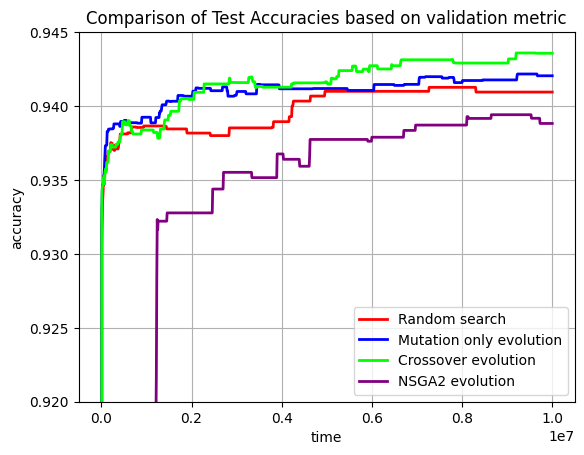

In [42]:
# Inspired by nasbench: https://github.com/google-research/nasbench/blob/master/NASBench.ipynb
# Compare the mean accuracy
def plot_data(data, color, label, gran=10000, max_budget=10000000):
  """Computes the mean for each algorithm"""
  xs = range(0, max_budget+1, gran)
  mean = [0.0]
  
  repeats = len(data)
  pointers = [1 for _ in range(repeats)]
  
  cur = gran
  while cur < max_budget+1:
    all_vals = []
    for repeat in range(repeats):
      while (pointers[repeat] < len(data[repeat][0]) and 
             data[repeat][0][pointers[repeat]] < cur):
        pointers[repeat] += 1
      prev_time = data[repeat][0][pointers[repeat]-1]
      prev_test = data[repeat][2][pointers[repeat]-1]
      next_time = data[repeat][0][pointers[repeat]]
      next_test = data[repeat][2][pointers[repeat]]
      assert prev_time < cur and next_time >= cur

      # Linearly interpolate the test between the two surrounding points
      cur_val = ((cur - prev_time) / (next_time - prev_time)) * (next_test - prev_test) + prev_test
      
      all_vals.append(cur_val)
      
    all_vals = sorted(all_vals)
    mean.append(sum(all_vals) / float(len(all_vals)))
      
    cur += gran
    
  plt.plot(xs, mean, color=color, label=label, linewidth=2)

plot_data(random_data, 'red', 'Random search')
plot_data(evolution_data_muton, 'blue', 'Mutation only evolution')
plot_data(evolution_data_cross, 'lime', 'Crossover evolution')
plot_data(evolution_data_NSGA2, 'purple', 'NSGA2 evolution')
plt.legend(loc='lower right')
plt.ylim(0.92, 0.945)
plt.xlabel('time')
plt.ylabel('accuracy')
plt.title('Comparison of Test Accuracies based on validation metric')
plt.grid()

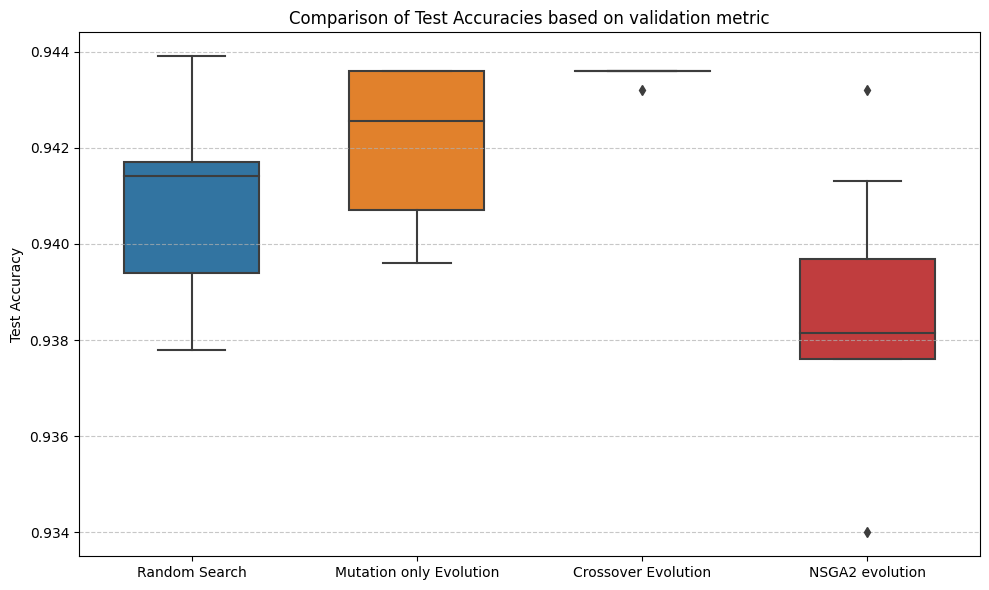

In [43]:
# Box plot graph
plt.figure(figsize=(10, 6))

# Prepare data
random_acc = [run[2][-1] for run in random_data]
evolution_acc = [run[2][-1] for run in evolution_data_muton]
evolution_cross_acc = [run[2][-1] for run in evolution_data_cross]
NSGA2_acc = [run[2][-1] for run in evolution_data_NSGA2]

# Create boxplot
boxplot_data = [random_acc, evolution_acc, evolution_cross_acc, NSGA2_acc]
labels = ['Random Search', 'Mutation only Evolution', 'Crossover Evolution', 'NSGA2 evolution']

sns.boxplot(data=boxplot_data, width=0.6)

# Set x-ticks
plt.xticks([0, 1, 2, 3], labels)
plt.ylabel('Test Accuracy')
plt.title('Comparison of Test Accuracies based on validation metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [25]:
# In this part we modify NSGA2 GA function to be able to plot pareto front
creator.create("FitnessMulti", base.Fitness, weights=(1.0, -1.0))
creator.create("Individual", tuple, fitness=creator.FitnessMulti)

def evaluate_spec(individual):
    spec = individual[2]
    data = nasbench.query(spec)
    params = data['trainable_parameters']
    if params > 15e6: # Some parameters have unreal values
        return 0.0, 1000000000
    return data['validation_accuracy'], data['trainable_parameters']

# NSGA2 implementation to minimize the number of trainable parameters
def run_GA_NSGA2_minimize(max_time_budget=10e6, 
                         population_size=1000, 
                         mutation_rate=1.0,
                         tournament_size=20, 
                         crossover_rate=0.5):
    nasbench.reset_budget_counters()
    toolbox = setup_nsga2_toolbox()
    times, best_valids, best_tests = [0.0], [0.0], [0.0]
    
    population = toolbox.population(n=population_size)
    
    # Evaluate initial population
    fitnesses = list(map(toolbox.evaluate, population))
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit
        time_spent, _ = nasbench.get_budget_counters()
        times.append(time_spent)
        
        if fit[0] > best_valids[-1]:
            best_valids.append(fit[0])
            test_acc = nasbench.query(ind[2])['test_accuracy']
            best_tests.append(test_acc)
        else:
            best_valids.append(best_valids[-1])  
            best_tests.append(best_tests[-1])
        
        if time_spent > max_time_budget:
            break
    
    front = tools.ParetoFront()
    all_fronts = []
    
    # Evolution loop
    while True:
        offspring = algorithms.varAnd(population, toolbox, cxpb=crossover_rate, mutpb=mutation_rate)
        
        # Evaluate offspring
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        for ind in invalid_ind:
            fit = toolbox.evaluate(ind)
            ind.fitness.values = fit
            time_spent, _ = nasbench.get_budget_counters()
            times.append(time_spent)
            
            if fit[0] > best_valids[-1]:
                best_valids.append(fit[0])
                test_acc = nasbench.query(ind[2])['test_accuracy']
                best_tests.append(test_acc)
            else:
                best_valids.append(best_valids[-1])
                best_tests.append(best_tests[-1])
        
        front.update(population + offspring)
        all_fronts.append(copy.deepcopy(list(front)))
        
        population = toolbox.select(population + offspring, population_size)
        
        time_spent, _ = nasbench.get_budget_counters()
        if time_spent > max_time_budget:
            break

    return times, best_valids, best_tests, all_fronts

In [26]:
# For plotting of pareto graph to extract non-dominated solutions
def get_pareto_front(population):
    pareto_front = []
    for ind in population:
        dominated = False
        for other in population:
            if dominates(other, ind):
                dominated = True
                break
        if not dominated:
            pareto_front.append(ind)
    return pareto_front

# Dominates function minimize number of trainable parameters and maximize accuracy
def dominates(ind1, ind2):
    acc1, params1, _ = ind1
    acc2, params2, _ = ind2
    better_acc = acc1 >= acc2
    better_params = params1 <= params2
    return (better_acc and better_params) and (acc1 > acc2 or params1 < params2)

# Tournament selection preferring architectures with:
# higher accuracy and larger parameter counts
def select_parent(population, tournament_size):
    tournament = random.sample(population, tournament_size)
    
    # Find solutions not dominated by others in tournament
    non_dominated = []
    for ind in tournament:
        is_dominated = False
        for other in tournament:
            if other != ind and dominates(other, ind):
                is_dominated = True
                break
        if not is_dominated:
            non_dominated.append(ind)
    
    # Randomly select from non-dominated, or entire tournament if none
    return random.choice(non_dominated if non_dominated else tournament)[2]

def crossover(parent1, parent2):
    """Combine two specs by merging their edges and operations."""
    # Merge adjacency matrices
    matrix_shape = parent1.original_matrix.shape # Dimension of the matrix
    mask = np.random.rand(*matrix_shape) # random matrix of same shape
    
    # Choose parents1 value if random > 0.5, else parents2
    new_matrix = np.where(mask > 0.5, parent1.original_matrix, parent2.original_matrix)
    
    # Merge operations
    new_ops = []
    for p1_op, p2_op in zip(parent1.original_ops, parent2.original_ops):
        if random.random() > 0.5:
            new_ops.append(p1_op)
        else:
            new_ops.append(p2_op)
    
    # Get all metrics from dataset for this new CNN
    new_spec = api.ModelSpec(new_matrix, new_ops)
    
    if nasbench.is_valid(new_spec):
        return new_spec
    else:
        return parent1

# GA algorithm, which combines crossover with mutation
def run_GA_cross_minimize(max_time_budget=10e6,
                 population_size=1000,
                 mutation_rate=1.0,
                 tournament_size=20,
                 crossover_rate=0.8,
                 elitism=5
                ):
    nasbench.reset_budget_counters()
    times, best_valids, best_tests = [0.0], [0.0], [0.0]
    population = []  # Stores (validation_accuracy, num_params, spec)

    # Initial population
    for _ in range(population_size):
        spec = random_spec()
        data = nasbench.query(spec)
        val_acc = data['validation_accuracy']
        num_params = data['trainable_parameters']
        time_spent, _ = nasbench.get_budget_counters()
        times.append(time_spent)
        
        population.append((val_acc, num_params, spec))
        
        # Update tracking
        if val_acc > best_valids[-1]:
            best_valids.append(val_acc)
            best_tests.append(data['test_accuracy'])
        else:
            best_valids.append(best_valids[-1])
            best_tests.append(best_tests[-1])
        
        if time_spent > max_time_budget:
            break

    # Evolution loop
    while True:
        new_population = []
        
        # Keep 5 best to new population
        best_5 = sorted(population, key=lambda x: (x[0], -x[1]), reverse=True)[:elitism]
        new_population.extend(best_5)
        
        for _ in range(population_size - elitism):
            # Parent selection and crossover
            if random.random() < crossover_rate and len(population) >= 2:
                parent1 = select_parent(population, tournament_size)
                parent2 = select_parent(population, tournament_size)
                child_spec = crossover(parent1, parent2)
            # Only mutation
            else:
                parent = select_parent(population, tournament_size)
                child_spec = mutate_spec(parent) if random.random() < mutation_rate else parent

            # Evaluate child
            data = nasbench.query(child_spec)
            val_acc = data['validation_accuracy']
            num_params = data['trainable_parameters']
            new_population.append((val_acc, num_params, child_spec))
            
            time_spent, _ = nasbench.get_budget_counters()
            times.append(time_spent)
            
            # Update tracking
            if val_acc > best_valids[-1]:
                best_valids.append(val_acc)
                best_tests.append(data['test_accuracy'])
            else:
                best_valids.append(best_valids[-1])
                best_tests.append(best_tests[-1])
            
            if time_spent > max_time_budget:
                break
        
        population = new_population
        time_spent, _ = nasbench.get_budget_counters()
        if time_spent > max_time_budget:
            break

    return times, best_valids, best_tests, population

# Same as run_GA_cross, but without crossover
def run_GA_mutonly_minimize(max_time_budget=10e6,
                   population_size=1000,
                   mutation_rate=1.0,
                   tournament_size=20,
                   elitism=5
                  ):
    nasbench.reset_budget_counters()
    times, best_valids, best_tests = [0.0], [0.0], [0.0]
    population = []  # Stores (validation_accuracy, num_params, spec)

    # Initial population
    for _ in range(population_size):
        spec = random_spec()
        data = nasbench.query(spec)
        val_acc = data['validation_accuracy']
        num_params = data['trainable_parameters']
        time_spent, _ = nasbench.get_budget_counters()
        times.append(time_spent)
        
        population.append((val_acc, num_params, spec))
        # Update tracking (single-objective)
        if val_acc > best_valids[-1]:
            best_valids.append(val_acc)
            best_tests.append(data['test_accuracy'])
        else:
            best_valids.append(best_valids[-1])
            best_tests.append(best_tests[-1])
        
        if time_spent > max_time_budget:
            break

    # Evolution loop
    while True:
        new_population = []
        
        # Keep 5 best to new population
        best_5 = sorted(population, key=lambda x: (x[0], -x[1]), reverse=True)[:elitism]
        new_population.extend(best_5)
        
        for _ in range(population_size - elitism):
            parent = select_parent(population, tournament_size)
            child_spec = mutate_spec(parent) if random.random() < mutation_rate else parent

            # Evaluate child
            data = nasbench.query(child_spec)
            val_acc = data['validation_accuracy']
            num_params = data['trainable_parameters']
            new_population.append((val_acc, num_params, child_spec))
            
            time_spent, _ = nasbench.get_budget_counters()
            times.append(time_spent)
            
            # Update tracking
            if val_acc > best_valids[-1]:
                best_valids.append(val_acc)
                best_tests.append(data['test_accuracy'])
            else:
                best_valids.append(best_valids[-1])
                best_tests.append(best_tests[-1])
            
            if time_spent > max_time_budget:
                break
        
        population = new_population
        time_spent, _ = nasbench.get_budget_counters()
        if time_spent > max_time_budget:
            break

    return times, best_valids, best_tests, population

In [27]:
# Inspired by nasbench: https://github.com/google-research/nasbench
evolution_data_NSGA2_minimize = []
evolution_data_cross_minimize = []
evolution_data_muton_minimize = []
for repeat in range(10):
  print('Running repeat %d' % (repeat + 1))
  times, best_valid, best_test, all_fronts_NSGA2 = run_GA_NSGA2_minimize()
  evolution_data_NSGA2_minimize.append((times, best_valid, best_test, all_fronts_NSGA2))

  times, best_valid, best_test, all_fronts_cross = run_GA_cross_minimize()
  evolution_data_cross_minimize.append((times, best_valid, best_test, all_fronts_cross))

  times, best_valid, best_test, all_fronts_mutonly = run_GA_mutonly_minimize()
  evolution_data_muton_minimize.append((times, best_valid, best_test, all_fronts_mutonly))


Running repeat 1
Running repeat 2
Running repeat 3
Running repeat 4
Running repeat 5
Running repeat 6
Running repeat 7
Running repeat 8
Running repeat 9
Running repeat 10


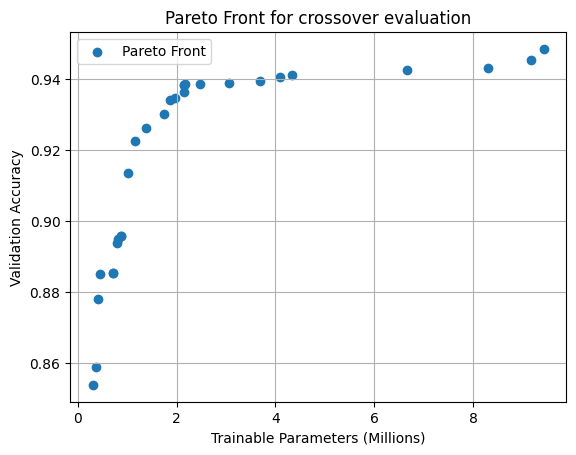

In [28]:
# Extract Pareto Front
final_front = get_pareto_front(all_fronts_cross)

# Prepare data for plotting
accuracies = [ind[0] for ind in final_front]
parameters = [ind[1]/1e6 for ind in final_front]

# Generate the plot
plt.scatter(parameters, accuracies, label="Pareto Front")
plt.xlabel("Trainable Parameters (Millions)")
plt.ylabel("Validation Accuracy")
plt.title("Pareto Front for crossover evaluation")
plt.grid(True)
plt.legend()
plt.show()

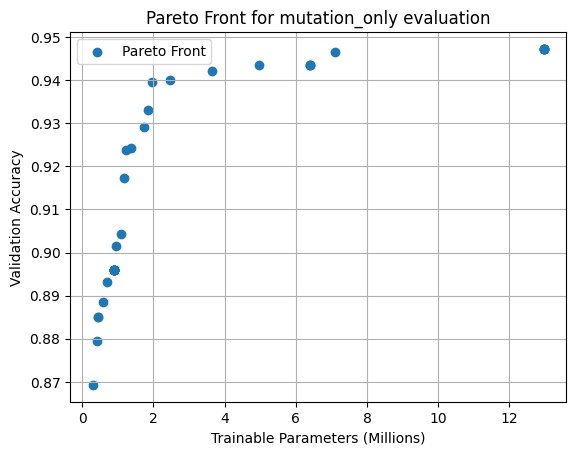

In [31]:
# Extract Pareto Front
final_front = get_pareto_front(all_fronts_mutonly)

# Prepare data for plotting
accuracies = [ind[0] for ind in final_front]
parameters = [ind[1]/1e6 for ind in final_front]  # Convert to millions

# Generate the plot
plt.scatter(parameters, accuracies, label="Pareto Front")
plt.xlabel("Trainable Parameters (Millions)")
plt.ylabel("Validation Accuracy")
plt.title("Pareto Front for mutation_only evaluation")
plt.grid(True)
plt.legend()
plt.show()

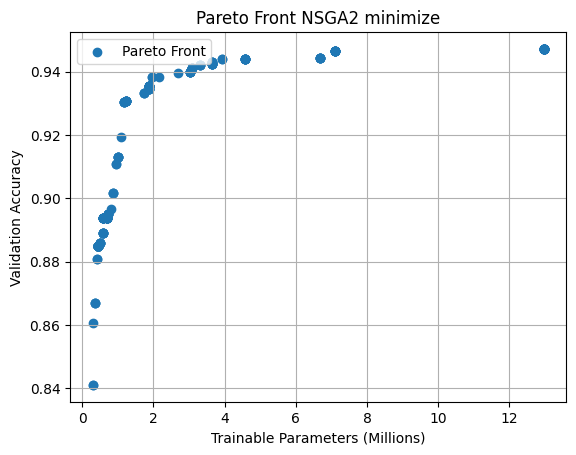

In [32]:
# Plot Pareto front (accuracy vs. parameters)
final_front = all_fronts_NSGA2[-1]
accuracies = [ind.fitness.values[0] for ind in final_front]
parameters = [ind.fitness.values[1]/1e6 for ind in final_front]

plt.scatter(parameters, accuracies, label="Pareto Front")
plt.xlabel("Trainable Parameters (Millions)")
plt.ylabel("Validation Accuracy")
plt.title("Pareto Front NSGA2 minimize")
plt.grid(True)
plt.legend()
plt.show()

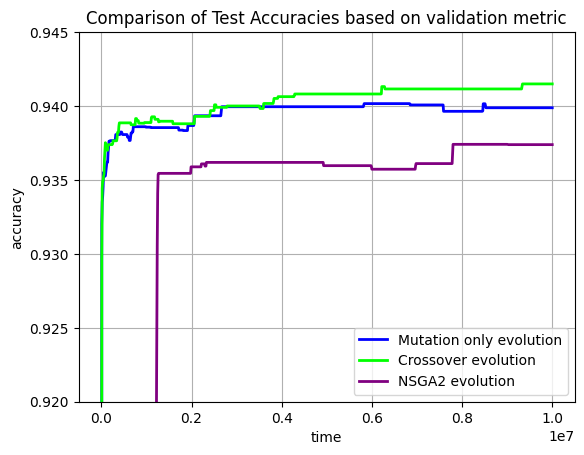

In [18]:
# These two cells are minimizing number of parameters
plot_data(evolution_data_muton_minimize, 'blue', 'Mutation only evolution')
plot_data(evolution_data_cross_minimize, 'lime', 'Crossover evolution')
plot_data(evolution_data_NSGA2_minimize, 'purple', 'NSGA2 evolution')
plt.legend(loc='lower right')
plt.ylim(0.92, 0.945)
plt.xlabel('time')
plt.ylabel('accuracy')
plt.title('Comparison of Test Accuracies based on validation metric')
plt.grid()

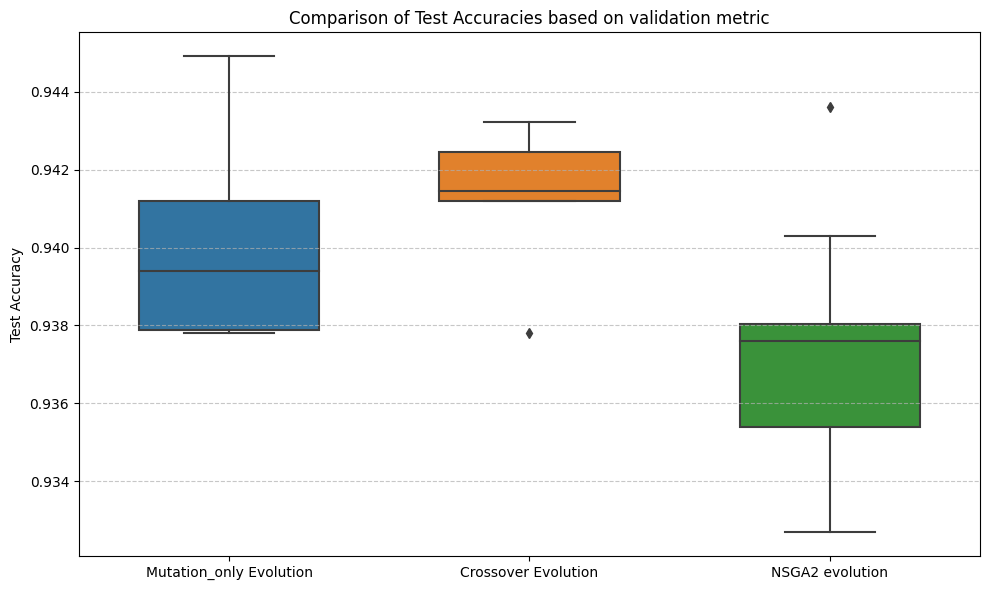

In [19]:
# Box plot graph
plt.figure(figsize=(10, 6))

# Prepare data
evolution_acc = [run[2][-1] for run in evolution_data_muton_minimize]
evolution_cross_acc = [run[2][-1] for run in evolution_data_cross_minimize]
NSGA2_acc = [run[2][-1] for run in evolution_data_NSGA2_minimize]

# Create boxplot
boxplot_data = [evolution_acc, evolution_cross_acc, NSGA2_acc]
labels = ['Mutation_only Evolution', 'Crossover Evolution', 'NSGA2 evolution']

sns.boxplot(data=boxplot_data, width=0.6)

# Set x-ticks
plt.xticks([0, 1, 2], labels)
plt.ylabel('Test Accuracy')
plt.title('Comparison of Test Accuracies based on validation metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
# plt.savefig('final_accuracy_boxplot.png', dpi=300)
plt.show()